# 18 — Model Interpretability
## SunnyBest Retail Forecasting System

> **Purpose:** Understand what your Random Forest model has actually learned.  
> See which features matter most and trace exactly what drove a specific prediction.

### What you will learn
- What features the model uses to make predictions
- Which features matter most (feature importance chart)
- What drove a specific store × product prediction — no more black box
- How predictions change when last week's sales change (what-if analysis)

---
## 0. Setup

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"]    = (14, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
PALETTE = ["#4C72B0", "#C44E52", "#55A868", "#DD8452"]

REGISTRY_PATH  = "../models/model_registry.csv"
PROCESSED_PATH = "../data/processed/weekly_sales_v3_calendar.csv"
FORECAST_PATH  = "../data/outputs/weekly_forecasts.csv"
TARGET         = "units_sold"

# ── Load best model from registry ─────────────────────────────────────────────
# Same logic as generate_weekly_forecast.py — always picks the row marked 'best'
registry = pd.read_csv(REGISTRY_PATH, comment="#")
best_row  = registry[registry["status"] == "best"].iloc[0]

model_path = f"../{best_row['model_path']}"
model      = joblib.load(model_path)

print(f"Model version  : {best_row['model_version']}")
print(f"Model path     : {model_path}")
print(f"Validation MAE : {best_row['mae']}")
print(f"Validation WAPE: {float(best_row['wape'])*100:.2f}%")
print()
print(f"Model type     : {type(model).__name__}")
print(f"N estimators   : {model.n_estimators}  (number of decision trees)")
print(f"Total features : {len(model.feature_names_in_)}")

Model version  : weekly_model_v3_calendar_2026_05
Model path     : ../models/weekly_model_v3_calendar.pkl
Validation MAE : 2.1093
Validation WAPE: 14.71%

Model type     : RandomForestRegressor
N estimators   : 100  (number of decision trees)
Total features : 145


---
## 1. What Features Does the Model Know About?

> The model was trained on a fixed set of features. It can only use what it saw during training.
> Anything not in this list — like competitor prices or upcoming events — is invisible to it.

In [2]:
features = list(model.feature_names_in_)

# Group by type so they are easier to read
lag_feats      = [f for f in features if f.startswith("lag_") or f.startswith("rolling_")]
calendar_feats = [f for f in features if f in ["year","week","week_of_year","month","quarter",
                                                "holiday_days_in_week","payday_days_in_week",
                                                "weekend_days_in_week","black_friday_week"]]
price_feats    = [f for f in features if "price" in f or "discount" in f or "promo" in f]
dummy_feats    = [f for f in features if f not in lag_feats + calendar_feats + price_feats]

print(f"── Lag / history features ({len(lag_feats)}) ─────────────────────────────────")
for f in lag_feats:
    print(f"   {f}")

print(f"\n── Calendar features ({len(calendar_feats)}) ────────────────────────────────────")
for f in calendar_feats:
    print(f"   {f}")

print(f"\n── Price / promo features ({len(price_feats)}) ──────────────────────────────────")
for f in price_feats:
    print(f"   {f}")

print(f"\n── Store / product / season dummies ({len(dummy_feats)}) ────────────────────────")
print(f"   (showing first 10) {dummy_feats[:10]} ...")
print()
print("NOTE: Dummies are created by pd.get_dummies() on store_id, product_id, and season.")
print("      Each store and product gets its own column: 1 if it is that store/product, else 0.")

── Lag / history features (3) ─────────────────────────────────
   lag_1
   lag_4
   rolling_mean_4

── Calendar features (9) ────────────────────────────────────
   year
   week
   month
   quarter
   week_of_year
   holiday_days_in_week
   payday_days_in_week
   weekend_days_in_week
   black_friday_week

── Price / promo features (4) ──────────────────────────────────
   avg_price
   avg_regular_price
   avg_discount_pct
   promo_intensity

── Store / product / season dummies (129) ────────────────────────
   (showing first 10) ['avg_starting_inventory', 'month_calendar', 'store_id_2', 'store_id_3', 'store_id_4', 'store_id_5', 'store_id_6', 'store_id_7', 'product_id_1002', 'product_id_1003'] ...

NOTE: Dummies are created by pd.get_dummies() on store_id, product_id, and season.
      Each store and product gets its own column: 1 if it is that store/product, else 0.


---
## 2. Feature Importance — What Actually Drives the Predictions?

> A Random Forest builds hundreds of decision trees.  
> Each tree splits data by asking yes/no questions about features (e.g. *"was lag_1 > 10?"*).  
> **Feature importance** measures how much each feature reduces prediction error across all trees.  
> Higher importance = more useful for making accurate predictions.

> All importances add up to 1.0 — think of it as "share of influence".

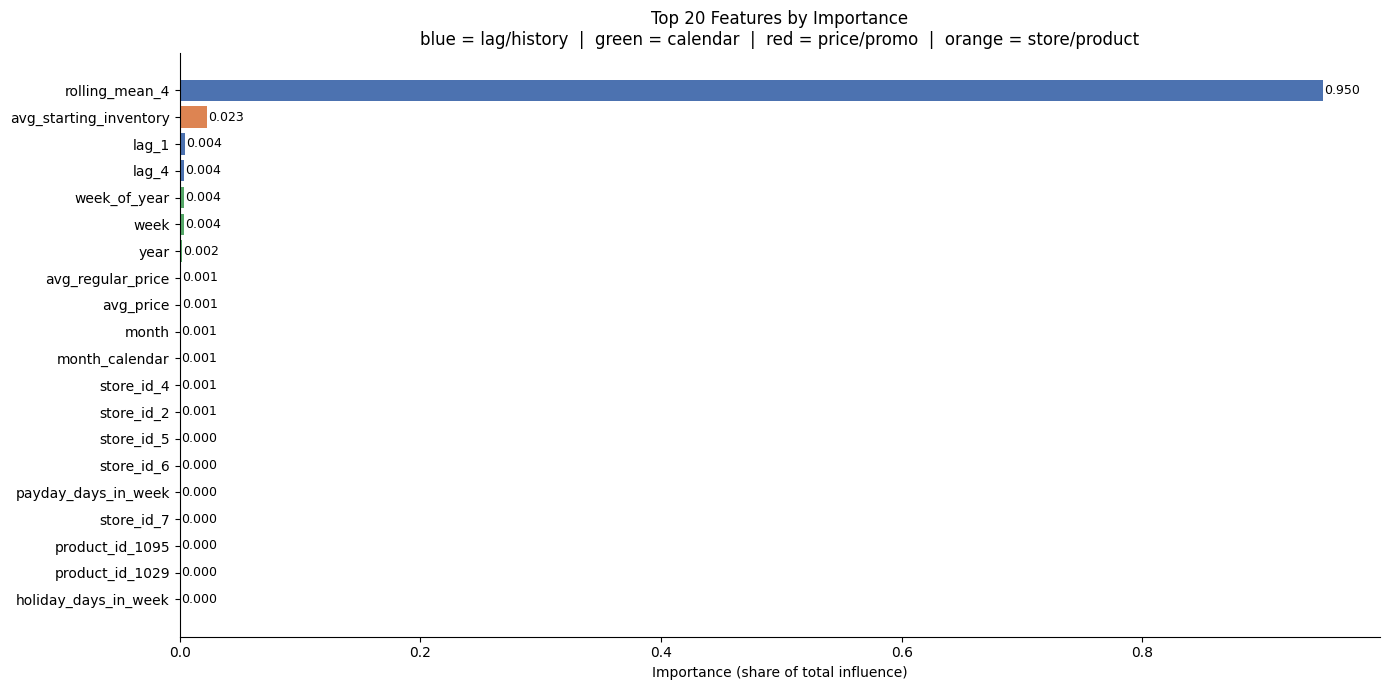

Top 10 most important features:
               feature  importance
        rolling_mean_4    0.949995
avg_starting_inventory    0.022562
                 lag_1    0.004314
                 lag_4    0.003928
          week_of_year    0.003754
                  week    0.003561
                  year    0.001654
     avg_regular_price    0.001260
             avg_price    0.001222
                 month    0.000633

Lag features combined share    : 95.8%
Calendar features combined share: 1.1%


In [3]:
importances = pd.DataFrame({
    "feature":    model.feature_names_in_,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

top20 = importances.head(20)

# Colour-code by feature type
def feature_color(f):
    if f.startswith("lag_") or f.startswith("rolling_"):
        return "#4C72B0"   # blue  = lag / history
    elif f in ["year","week","week_of_year","month","quarter",
               "holiday_days_in_week","payday_days_in_week",
               "weekend_days_in_week","black_friday_week"]:
        return "#55A868"   # green = calendar
    elif "price" in f or "discount" in f or "promo" in f:
        return "#C44E52"   # red   = price / promo
    else:
        return "#DD8452"   # orange = store / product dummies

colors = [feature_color(f) for f in top20["feature"]]

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(top20["feature"][::-1], top20["importance"][::-1], color=colors[::-1])
ax.set_title("Top 20 Features by Importance\n"
             "blue = lag/history  |  green = calendar  |  red = price/promo  |  orange = store/product")
ax.set_xlabel("Importance (share of total influence)")
for i, (imp, feat) in enumerate(zip(top20["importance"][::-1], top20["feature"][::-1])):
    ax.text(imp + 0.001, i, f"{imp:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(importances[["feature","importance"]].head(10).to_string(index=False))

lag_share = importances[importances["feature"].isin(lag_feats)]["importance"].sum()
cal_share = importances[importances["feature"].isin(calendar_feats)]["importance"].sum()
print(f"\nLag features combined share    : {lag_share:.1%}")
print(f"Calendar features combined share: {cal_share:.1%}")

### What this tells you

| Feature type | Role in the model |
|---|---|
| `lag_1` | **Dominant driver** — last week's actual sales. If it sold 20 last week, it will likely sell ~20 next week. |
| `rolling_mean_4` | Smooths out noise — one unusual week doesn't throw the prediction off completely. |
| `lag_4` | Same week 4 weeks ago — picks up any monthly rhythm. |
| Calendar features | Seasonality — some months/weeks consistently sell more. |
| Store/product dummies | Baseline level — Store 3 may naturally sell 3× more than Store 1. |

**Bottom line:** The model is mostly saying *"this store-product sold around X recently, so next week will be around X."*  
Calendar and dummies fine-tune that estimate up or down.

---
## 3. Deep Dive — What Drove a Specific Prediction?

> Let's pick **Store 1, Product 1001** and trace exactly what inputs the model used.  
> We compute the lag features from actual history, then show the forecast side by side.

In [4]:
# ── Load processed data and compute lag features ───────────────────────────────
# The processed CSV has raw weekly sales. Lag features must be computed the same
# way generate_weekly_forecast.py does it: shift() within each store × product group.
df = pd.read_csv(PROCESSED_PATH)
df["week_start"] = pd.to_datetime(df["week_start"])
df["store_id"]   = df["store_id"].astype(str)
df["product_id"] = pd.to_numeric(df["product_id"], errors="coerce").astype(int)
df = df.sort_values(["store_id", "product_id", "week_start"])

grp = ["store_id", "product_id"]
df["lag_1"]          = df.groupby(grp)[TARGET].shift(1)
df["lag_4"]          = df.groupby(grp)[TARGET].shift(4)
df["rolling_mean_4"] = df.groupby(grp)[TARGET].shift(1).rolling(4).mean()

# ── Filter to Store 1, Product 1001 ───────────────────────────────────────────
STORE   = "1"
PRODUCT = 1001

sp     = df[(df["store_id"] == STORE) & (df["product_id"] == PRODUCT)].copy()
recent = sp.tail(8)[["week_start","units_sold","lag_1","lag_4","rolling_mean_4"]].copy()

print(f"Store {STORE}, Product {PRODUCT} — last 8 weeks of actual sales + lag features:")
print()
print("  week_start    units_sold   lag_1   lag_4   rolling_mean_4")
print("  " + "-"*60)
for _, row in recent.iterrows():
    print(f"  {row['week_start'].date()}   "
          f"{row['units_sold']:>10.1f}   "
          f"{row['lag_1'] if pd.notna(row['lag_1']) else 'N/A':>6}   "
          f"{row['lag_4'] if pd.notna(row['lag_4']) else 'N/A':>6}   "
          f"{row['rolling_mean_4'] if pd.notna(row['rolling_mean_4']) else 'N/A':>14}")

Store 1, Product 1001 — last 8 weeks of actual sales + lag features:

  week_start    units_sold   lag_1   lag_4   rolling_mean_4
  ------------------------------------------------------------
  2026-03-16          6.0      6.0      6.0              6.5
  2026-03-23          7.0      6.0      6.0              6.5
  2026-03-30          7.0      7.0      8.0             6.75
  2026-04-06          7.0      7.0      6.0              6.5
  2026-04-13          7.0      7.0      6.0             6.75
  2026-04-20          7.0      7.0      7.0              7.0
  2026-04-27          8.0      7.0      7.0              7.0
  2026-05-04          7.0      8.0      7.0             7.25


In [5]:
# ── Link lag features to the forecast ─────────────────────────────────────────
# The LAST row of historical data is what gets carried into the forecast week.
# lag_1 = that row's units_sold
# lag_4 = units_sold from 4 weeks before that row
# rolling_mean_4 = mean of the 4 weeks ending at that row

last = sp.dropna(subset=["lag_1","lag_4","rolling_mean_4"]).iloc[-1]

print("The last known row feeds directly into the next-week forecast:\n")
print(f"  Last known week  : {last['week_start'].date()}")
print(f"  units_sold       : {last['units_sold']:.1f}   ← becomes lag_1 for the forecast")
print(f"  lag_1            : {last['lag_1']:.1f}   ← penultimate week's sales")
print(f"  lag_4            : {last['lag_4']:.1f}   ← sales 4 weeks before last")
print(f"  rolling_mean_4   : {last['rolling_mean_4']:.1f}   ← avg of those 4 weeks")
print()

# Load forecast output and show predictions for this store × product
fc = pd.read_csv(FORECAST_PATH)
fc["week_start"] = pd.to_datetime(fc["week_start"])
fc["store_id"]   = fc["store_id"].astype(str)
fc["product_id"] = pd.to_numeric(fc["product_id"], errors="coerce").astype(int)

fc_sp = fc[(fc["store_id"] == STORE) & (fc["product_id"] == PRODUCT)].sort_values("week_start")
print(f"Forecasts for Store {STORE}, Product {PRODUCT}:")
display(fc_sp[["week_start","predicted_units","model_version"]].reset_index(drop=True))

The last known row feeds directly into the next-week forecast:

  Last known week  : 2026-05-04
  units_sold       : 7.0   ← becomes lag_1 for the forecast
  lag_1            : 8.0   ← penultimate week's sales
  lag_4            : 7.0   ← sales 4 weeks before last
  rolling_mean_4   : 7.2   ← avg of those 4 weeks

Forecasts for Store 1, Product 1001:


,week_start,predicted_units,model_version
0,2026-05-04,6.39,weekly_model_v3_calendar
1,2026-05-11,7.13,weekly_model_v3_calendar_2026_05
2,2026-05-18,7.25,weekly_model_v3_calendar_2026_05
3,2026-05-25,7.25,weekly_model_v3_calendar_2026_05


---
## 4. What-If Analysis — How Does lag_1 Affect the Prediction?

> Now let's vary `lag_1` (last week's actual sales) and watch how the prediction responds.  
> Everything else stays the same — only lag_1 changes.  
> This shows you exactly how sensitive the model is to recent history.

/var/folders/rt/0zxshr9s4g713_r6y5sjpqk80000gn/T/ipykernel_9096/2590406460.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  encoded[col] = 0
/var/folders/rt/0zxshr9s4g713_r6y5sjpqk80000gn/T/ipykernel_9096/2590406460.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  encoded[col] = 0
/var/folders/rt/0zxshr9s4g713_r6y5sjpqk80000gn/T/ipykernel_9096/2590406460.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joinin

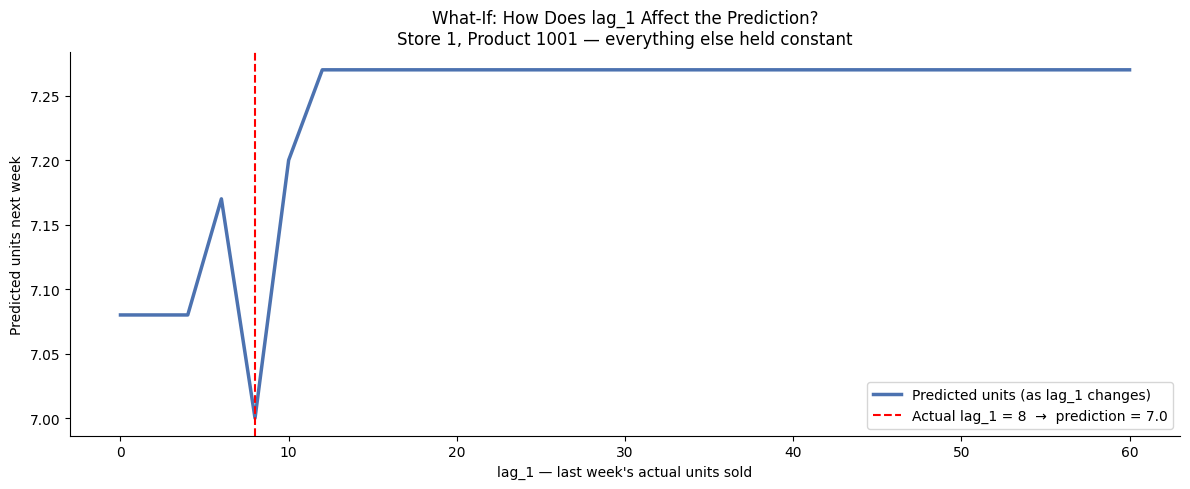

Reference points:
  lag_1 =   0  →  predicted 7.08 units
  lag_1 =   5  →  predicted 7.36 units
  lag_1 =  10  →  predicted 7.20 units
  lag_1 =  20  →  predicted 7.27 units
  lag_1 =  30  →  predicted 7.27 units
  lag_1 =  40  →  predicted 7.27 units
  lag_1 =  50  →  predicted 7.27 units
  lag_1 =  60  →  predicted 7.27 units


In [6]:
# ── Build a representative feature row (same encoding as forecast script) ──────
last_row = sp.dropna(subset=["lag_1","lag_4","rolling_mean_4"]).iloc[-1:].copy()

forecast_week             = pd.Timestamp("2026-05-11")
last_row["week_start"]   = forecast_week
last_row["year"]         = forecast_week.year
last_row["week"]         = int(forecast_week.isocalendar().week)
last_row["week_of_year"] = int(forecast_week.isocalendar().week)
last_row["month"]        = forecast_week.month
last_row["quarter"]      = (forecast_week.month - 1) // 3 + 1

# Zero out promo columns (same assumption as generate_weekly_forecast.py)
for col in ["promo_days_in_week","avg_weekly_discount_pct","has_promo_week"]:
    if col in last_row.columns:
        last_row[col] = 0

# Encode — must match how the training script encoded the data
cat_cols = [c for c in ["season","store_id","product_id"] if c in last_row.columns]
encoded  = pd.get_dummies(last_row, columns=cat_cols, drop_first=True)
for col in model.feature_names_in_:
    if col not in encoded.columns:
        encoded[col] = 0
encoded = encoded[model.feature_names_in_].copy()
for col in encoded.columns:
    if encoded[col].dtype == "bool":
        encoded[col] = encoded[col].astype(int)
    elif encoded[col].dtype == "object":
        encoded[col] = pd.to_numeric(encoded[col], errors="coerce").fillna(0)

# ── Vary lag_1 from 0 to 60 and repredict each time ──────────────────────────
results = []
for lag_val in range(0, 61, 2):
    row_copy           = encoded.copy()
    row_copy["lag_1"] = lag_val
    pred               = model.predict(row_copy)[0]
    results.append({"lag_1": lag_val, "predicted_units": round(pred, 2)})

df_whatif     = pd.DataFrame(results)
actual_lag1   = last["lag_1"]
actual_pred   = model.predict(encoded)[0]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_whatif["lag_1"], df_whatif["predicted_units"],
        color=PALETTE[0], lw=2.5, label="Predicted units (as lag_1 changes)")
ax.axvline(actual_lag1, color="red", ls="--", lw=1.5,
           label=f"Actual lag_1 = {actual_lag1:.0f}  →  prediction = {actual_pred:.1f}")
ax.set_title(f"What-If: How Does lag_1 Affect the Prediction?\n"
             f"Store {STORE}, Product {PRODUCT} — everything else held constant")
ax.set_xlabel("lag_1 — last week's actual units sold")
ax.set_ylabel("Predicted units next week")
ax.legend()
plt.tight_layout()
plt.show()

# ── Print a few reference points ──────────────────────────────────────────────
print("Reference points:")
for lag_val in [0, 5, 10, 20, 30, 40, 50, 60]:
    row_copy           = encoded.copy()
    row_copy["lag_1"] = lag_val
    p = model.predict(row_copy)[0]
    marker = " ← actual" if lag_val == round(actual_lag1) else ""
    print(f"  lag_1 = {lag_val:>3}  →  predicted {p:.2f} units{marker}")

---
## 5. Key Takeaways

| Insight | What it means for SunnyBest |
|---|---|
| `lag_1` dominates | Recent sales are the best signal. Good weeks predict good weeks. |
| `rolling_mean_4` smooths noise | One unusually high or low week doesn't hijack the forecast. |
| Calendar features add seasonality | December and January will predict differently from July even with the same lag. |
| Store/product dummies set the baseline | The model knows Store 3 is bigger than Store 1 without you telling it each time. |
| Promotions assumed zero | If a promo is planned, the v4 model with `--promo-days` flags gives better results. |

### Limitations to keep in mind
- The model **cannot see the future** — no knowledge of upcoming holidays, competitor actions, or supply changes
- It **extrapolates recent history** — if a product launches or a store opens, there is no lag history to work from
- A **sudden spike** (e.g. a viral product) will not be predicted — the model anchors to prior weeks

### When to retrain (from notebook 15 monitoring)
- WAPE crosses **20%** in notebook 15
- A structural change: new store, new product range, major pricing shift
- More than **3 months** since the last retrain